In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#To load training and testing sets
df_80 = pd.read_csv('churn-bigml-80.csv')
df_20 = pd.read_csv('churn-bigml-20.csv')

#To combine into one complete dataset for customized preprocessing
df = pd.concat([df_80, df_20], ignore_index=True)

#To clean whitespace from column headers
df.columns = df.columns.str.strip()

print("Dataset successfully loaded!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head()

Dataset successfully loaded!
Total Rows: 3333 | Total Columns: 20


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate Features (X) and Target Variable (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)  # Convert True/False to 1/0

# Convert categorical features (International plan, Voice mail plan, State) into numerical format
X_encoded = pd.get_dummies(X, columns=['International plan', 'Voice mail plan', 'State'], drop_first=True)

# 80/20 Train-Test Split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (2666, 68)
Testing Features Shape: (667, 68)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average='weighted'), 4),
        "Recall": round(recall_score(y_test, preds, average='weighted'), 4),
        "F1-Score": round(f1_score(y_test, preds, average='weighted'), 4)
    })

# Compare model performance
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8636     0.8404  0.8636    0.8445
1        Decision Tree    0.9265     0.9275  0.9265    0.9270
2        Random Forest    0.9355     0.9375  0.9355    0.9285


In [6]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest optimization
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Run Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best Parameters from GridSearch:")
print(grid_search.best_params_)

Best Parameters from GridSearch:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


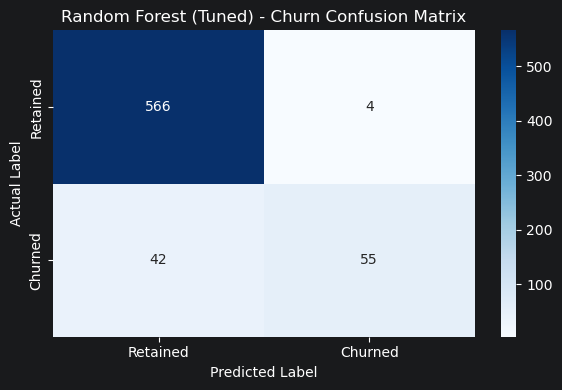

In [7]:
from sklearn.metrics import confusion_matrix

best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, best_preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned']
)
plt.title('Random Forest (Tuned) - Churn Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()

# Save image file for repository push
plt.savefig('churn_confusion_matrix.png')
plt.show()

In [8]:
# Inspect actual vs predicted churn for the first 10 test customers
comparison_df = pd.DataFrame({
    'Actual_Churn': y_test.values[:10],
    'Predicted_Churn': best_preds[:10],
    'Churn_Probability_%': np.round(best_rf.predict_proba(X_test)[:10, 1] * 100, 2)
})

comparison_df

,Actual_Churn,Predicted_Churn,Churn_Probability_%
0,1,0,36.76
1,0,0,1.33
2,0,0,8.63
3,0,0,6.30
4,0,0,9.63
5,0,0,5.50
6,0,0,2.95
7,0,0,6.60
8,0,0,20.70
9,0,0,1.33
